In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.arange(0,10, 0.5)
x

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ,
       6.5, 7. , 7.5, 8. , 8.5, 9. , 9.5])

In [3]:
vals = np.arange(0,1, 0.1)

In [4]:
def DFT(x):
  N = len(x)
  transformada = np.zeros(N,dtype=complex)

  for n in range(N):
    suma = 0
    w = -1j * ((2 * np.pi)/N) * n

    for k in range(N):
      suma += x[k] * np.exp(w * k)

    transformada[n] = suma


  return transformada

In [5]:
def convertir_complejos(nums):
  result = np.zeros(len(nums))

  for i in range(len(nums)):
    result[i] = np.sqrt(nums[i].real**2 + nums[i].imag**2)

  return result

In [6]:
print(f'Valores transformada: {DFT(vals)}')
print(f'Valores reales: {convertir_complejos(DFT(vals))}')

Valores transformada: [ 4.5+0.00000000e+00j -0.5+1.53884177e+00j -0.5+6.88190960e-01j
 -0.5+3.63271264e-01j -0.5+1.62459848e-01j -0.5-5.51091060e-16j
 -0.5-1.62459848e-01j -0.5-3.63271264e-01j -0.5-6.88190960e-01j
 -0.5-1.53884177e+00j]
Valores reales: [4.5        1.61803399 0.85065081 0.61803399 0.52573111 0.5
 0.52573111 0.61803399 0.85065081 1.61803399]


El comando np.abs() cumple la misma función que 'convertir_complejos'

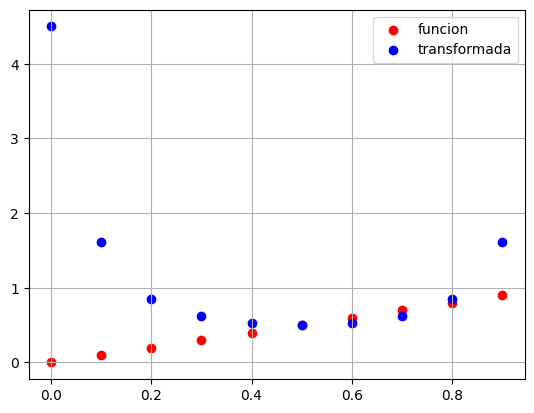

In [7]:
plt.scatter(vals, vals, color='red', label='funcion')
plt.scatter(vals,convertir_complejos(DFT(vals)), color='blue', label='transformada')
plt.grid(True)
plt.legend()
plt.show()

In [28]:
def DFT(x):
    N = len(x)
    
    # Vector frecuencias discretas
    X = np.zeros(N, dtype=complex)

    for n in range(N):          # índice de frecuencia
        suma = 0

        for k in range(N):      # índice temporal / muestra
            suma += x[k] * np.exp(-1j * 2 * np.pi * n * k / N)

        X[n] = suma

    return X



Frecuencia 4: amplitud 1.9999999999999998
Frecuencia 12: amplitud 0.6999999999999998


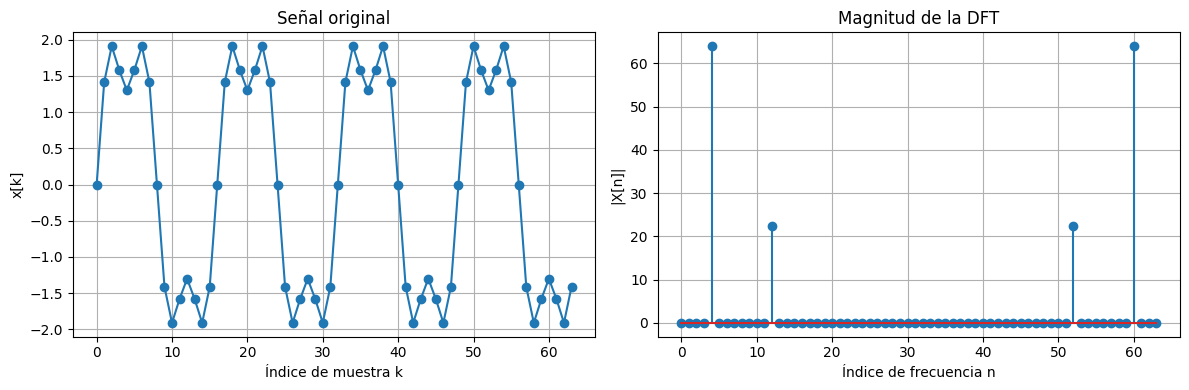

In [32]:
# Suma de 2 ondas

N = 64
k = np.arange(N)

# Elegí una señal:
x = (
    2 * np.sin(2 * np.pi * 4 * k / N)
    + 0.7 * np.sin(2 * np.pi * 12 * k / N)
)

X = DFT(x)

n = np.arange(N)

# Nos quedamos con frecuencias positivas
freqs = np.arange(N//2 + 1)

# Amplitudes normalizadas
amp = np.abs(X[:N//2 + 1]) / N

# Duplicamos las frecuencias interiores
amp[1:-1] = 2 * amp[1:-1]

tol = 1e-10

freqs_presentes = np.where(amp > tol)[0]

for f in freqs_presentes:
    print(f"Frecuencia {f}: amplitud {amp[f]}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k, x, marker='o')
plt.xlabel("Índice de muestra k")
plt.ylabel("x[k]")
plt.title("Señal original")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, np.abs(X))
plt.xlabel("Índice de frecuencia n")
plt.ylabel("|X[n]|")
plt.title("Magnitud de la DFT")
plt.grid(True)

plt.tight_layout()
plt.show()



Frecuencia 0: amplitud 0.05497763818226035
Frecuencia 1: amplitud 0.1021578916835213
Frecuencia 2: amplitud 0.06339513023969172
Frecuencia 3: amplitud 0.06469817204952615
Frecuencia 4: amplitud 0.11135800746348071
Frecuencia 5: amplitud 0.9223280147320652
Frecuencia 6: amplitud 0.01860210565572834
Frecuencia 7: amplitud 0.09511648965791362
Frecuencia 8: amplitud 0.10850744085731813
Frecuencia 9: amplitud 0.04843507701345717
Frecuencia 10: amplitud 0.08670183476318284
Frecuencia 11: amplitud 0.12590712066805643
Frecuencia 12: amplitud 0.09263511456027496
Frecuencia 13: amplitud 0.015489274416645783
Frecuencia 14: amplitud 0.15836319674632648
Frecuencia 15: amplitud 0.1609886115032164
Frecuencia 16: amplitud 0.08878293325273331
Frecuencia 17: amplitud 0.16917799045095439
Frecuencia 18: amplitud 0.1538085146140064
Frecuencia 19: amplitud 0.14678785827662055
Frecuencia 20: amplitud 0.19266729838442034
Frecuencia 21: amplitud 0.07060805207612454
Frecuencia 22: amplitud 0.0709158659563088
Fr

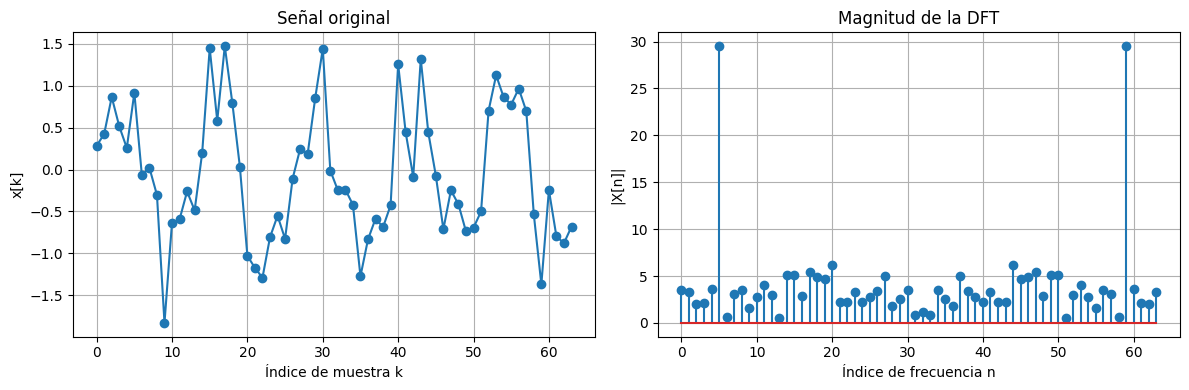

In [33]:
N = 64
k = np.arange(N)

# Elegí una señal:
x_limpia = np.sin(2 * np.pi * 5 * k / N)
ruido = 0.4 * np.random.randn(N)

x = x_limpia + ruido

X = DFT(x)

n = np.arange(N)

# Nos quedamos con frecuencias positivas
freqs = np.arange(N//2 + 1)

# Amplitudes normalizadas
amp = np.abs(X[:N//2 + 1]) / N

# Duplicamos las frecuencias interiores
amp[1:-1] = 2 * amp[1:-1]

tol = 1e-10

freqs_presentes = np.where(amp > tol)[0]

for f in freqs_presentes:
    print(f"Frecuencia {f}: amplitud {amp[f]}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k, x, marker='o')
plt.xlabel("Índice de muestra k")
plt.ylabel("x[k]")
plt.title("Señal original")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, np.abs(X))
plt.xlabel("Índice de frecuencia n")
plt.ylabel("|X[n]|")
plt.title("Magnitud de la DFT")
plt.grid(True)

plt.tight_layout()
plt.show()

Frecuencia 0: amplitud 31.5
Frecuencia 1: amplitud 20.380016247096115
Frecuencia 2: amplitud 10.202297237378326
Frecuencia 3: amplitud 6.815216836937437
Frecuencia 4: amplitud 5.125830895483012
Frecuencia 5: amplitud 4.115562019906831
Frecuencia 6: amplitud 3.4448941964766715
Frecuencia 7: amplitud 2.9683292326283315
Frecuencia 8: amplitud 2.6131259297527487
Frecuencia 9: amplitud 2.338879866865739
Frecuencia 10: amplitud 2.121355371980691
Frecuencia 11: amplitud 1.9451364757239216
Frecuencia 12: amplitud 1.7999524462728198
Frecuencia 13: amplitud 1.6786992908310676
Frecuencia 14: amplitud 1.5763092469024884
Frecuencia 15: amplitud 1.4890725420045905
Frecuencia 16: amplitud 1.4142135623730905
Frecuencia 17: amplitud 1.349616682910004
Frecuencia 18: amplitud 1.2936435667199655
Frecuencia 19: amplitud 1.2450082460713254
Frecuencia 20: amplitud 1.202689773870091
Frecuencia 21: amplitud 1.165869936412237
Frecuencia 22: amplitud 1.1338880696327158
Frecuencia 23: amplitud 1.10620779206896
Fr

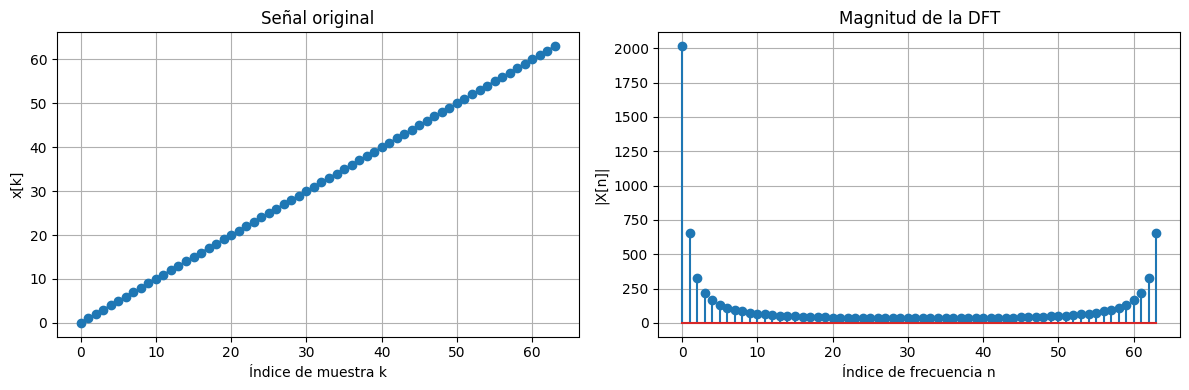

In [34]:
N = 64
k = np.arange(N)

# Elegí una señal:
x = k

X = DFT(x)

n = np.arange(N)

# Nos quedamos con frecuencias positivas
freqs = np.arange(N//2 + 1)

# Amplitudes normalizadas
amp = np.abs(X[:N//2 + 1]) / N

# Duplicamos las frecuencias interiores
amp[1:-1] = 2 * amp[1:-1]

tol = 1e-10

freqs_presentes = np.where(amp > tol)[0]

for f in freqs_presentes:
    print(f"Frecuencia {f}: amplitud {amp[f]}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k, x, marker='o')
plt.xlabel("Índice de muestra k")
plt.ylabel("x[k]")
plt.title("Señal original")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, np.abs(X))
plt.xlabel("Índice de frecuencia n")
plt.ylabel("|X[n]|")
plt.title("Magnitud de la DFT")
plt.grid(True)

plt.tight_layout()
plt.show()

Frecuencia 0: amplitud 0.0078125
Frecuencia 1: amplitud 0.018727451945927634
Frecuencia 2: amplitud 0.015625000000000056
Frecuencia 3: amplitud 0.047042307440031815
Frecuencia 4: amplitud 0.015625000000000097
Frecuencia 5: amplitud 1.2730797604462074
Frecuencia 6: amplitud 0.015625000000000003
Frecuencia 7: amplitud 0.04298367642626835
Frecuencia 8: amplitud 0.01562500000000005
Frecuencia 9: amplitud 0.017858589404330667
Frecuencia 10: amplitud 0.01562500000000008
Frecuencia 11: amplitud 0.019734500628891278
Frecuencia 12: amplitud 0.01562500000000032
Frecuencia 13: amplitud 0.051763679496700646
Frecuencia 14: amplitud 0.015625000000000628
Frecuencia 15: amplitud 0.4239339582108983
Frecuencia 16: amplitud 0.015624999999999842
Frecuencia 17: amplitud 0.03945336035117277
Frecuencia 18: amplitud 0.015625000000000076
Frecuencia 19: amplitud 0.017128480342929412
Frecuencia 20: amplitud 0.015625000000000246
Frecuencia 21: amplitud 0.02088117100836828
Frecuencia 22: amplitud 0.015624999999999

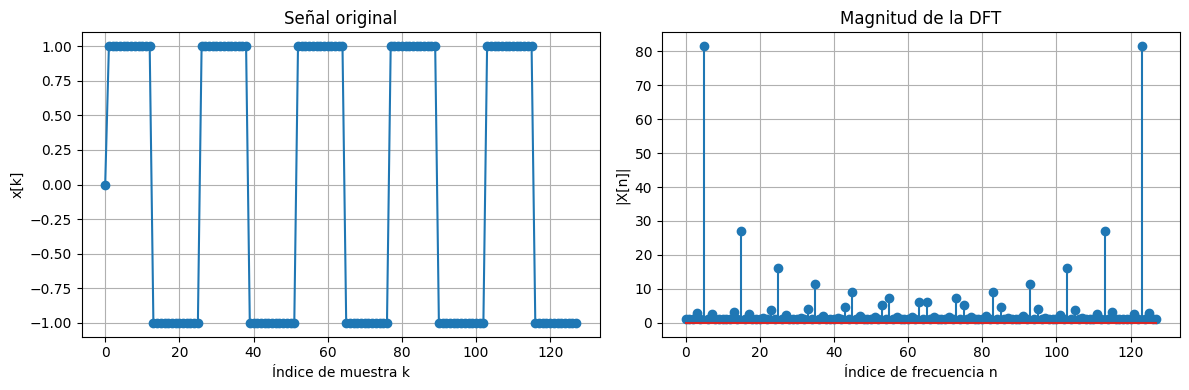

In [35]:
# Onda cuadrada

N = 128
k = np.arange(N)

x = np.sign(np.sin(2 * np.pi * 5 * k / N))

X = DFT(x)

n = np.arange(N)

# Nos quedamos con frecuencias positivas
freqs = np.arange(N//2 + 1)

# Amplitudes normalizadas
amp = np.abs(X[:N//2 + 1]) / N

# Duplicamos las frecuencias interiores
amp[1:-1] = 2 * amp[1:-1]

tol = 1e-10

freqs_presentes = np.where(amp > tol)[0]

for f in freqs_presentes:
    print(f"Frecuencia {f}: amplitud {amp[f]}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k, x, marker='o')
plt.xlabel("Índice de muestra k")
plt.ylabel("x[k]")
plt.title("Señal original")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, np.abs(X))
plt.xlabel("Índice de frecuencia n")
plt.ylabel("|X[n]|")
plt.title("Magnitud de la DFT")
plt.grid(True)

plt.tight_layout()
plt.show()

Frecuencia 0: amplitud 0.234375
Frecuencia 1: amplitud 0.42757063525520084
Frecuencia 2: amplitud 0.3169043890381449
Frecuencia 3: amplitud 0.17060004253789676
Frecuencia 4: amplitud 0.031099522708506164
Frecuencia 5: amplitud 0.06562218013213379
Frecuencia 6: amplitud 0.1019024357504174
Frecuencia 7: amplitud 0.08261977454435862
Frecuencia 8: amplitud 0.030649540012601013
Frecuencia 9: amplitud 0.024024984776374055
Frecuencia 10: amplitud 0.056712525939067136
Frecuencia 11: amplitud 0.05682794656941456
Frecuencia 12: amplitud 0.029904385491631547
Frecuencia 13: amplitud 0.007308884669058595
Frecuencia 14: amplitud 0.035852336341310874
Frecuencia 15: amplitud 0.04336314041299243
Frecuencia 16: amplitud 0.028871235390977672
Frecuencia 17: amplitud 0.001891915717548195
Frecuencia 18: amplitud 0.023183901250081483
Frecuencia 19: amplitud 0.034376097639872503
Frecuencia 20: amplitud 0.027560039510886057
Frecuencia 21: amplitud 0.0077025344601356184
Frecuencia 22: amplitud 0.014327046677148

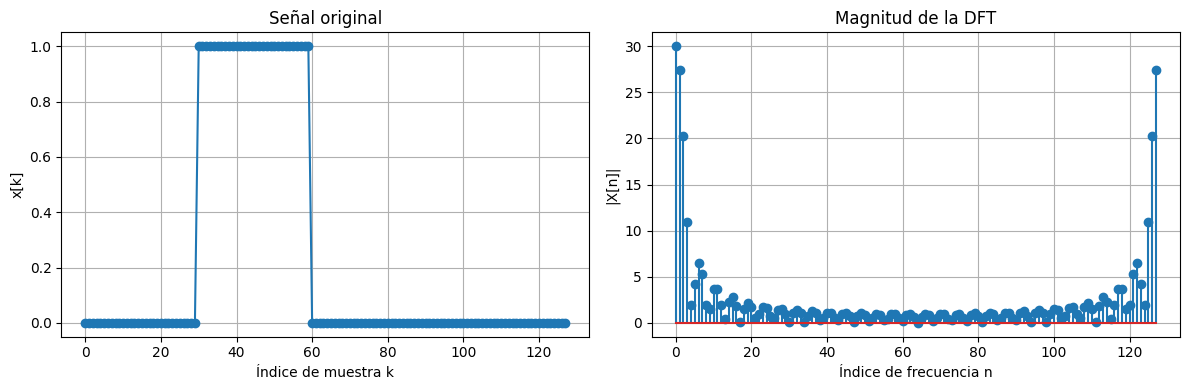

In [36]:
N = 128
k = np.arange(N)

x = np.zeros(N)
x[30:60] = 1
X = DFT(x)

n = np.arange(N)

# Nos quedamos con frecuencias positivas
freqs = np.arange(N//2 + 1)

# Amplitudes normalizadas
amp = np.abs(X[:N//2 + 1]) / N

# Duplicamos las frecuencias interiores
amp[1:-1] = 2 * amp[1:-1]

tol = 1e-10

freqs_presentes = np.where(amp > tol)[0]

for f in freqs_presentes:
    print(f"Frecuencia {f}: amplitud {amp[f]}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k, x, marker='o')
plt.xlabel("Índice de muestra k")
plt.ylabel("x[k]")
plt.title("Señal original")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, np.abs(X))
plt.xlabel("Índice de frecuencia n")
plt.ylabel("|X[n]|")
plt.title("Magnitud de la DFT")
plt.grid(True)

plt.tight_layout()
plt.show()

Frecuencia 32: amplitud 1.0


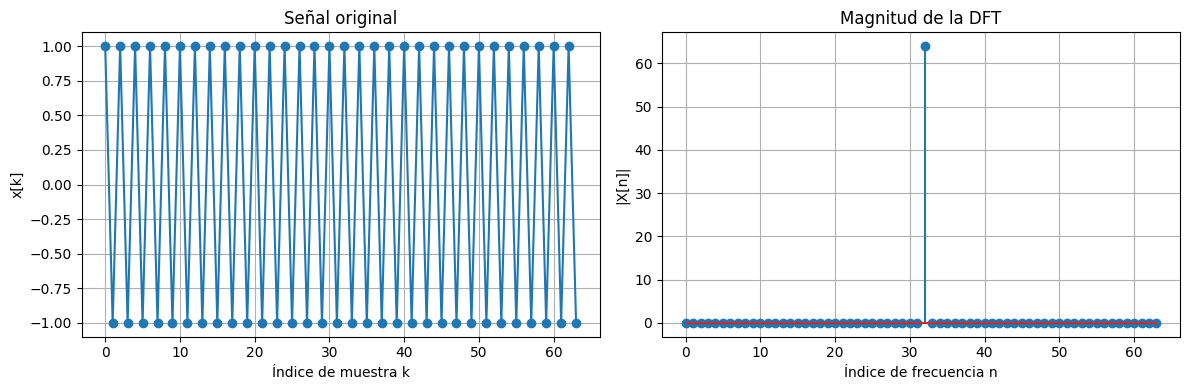

In [37]:
# Señal alternante
N = 64
k = np.arange(N)

x = (-1)**k

X = DFT(x)

n = np.arange(N)

# Nos quedamos con frecuencias positivas
freqs = np.arange(N//2 + 1)

# Amplitudes normalizadas
amp = np.abs(X[:N//2 + 1]) / N

# Duplicamos las frecuencias interiores
amp[1:-1] = 2 * amp[1:-1]

tol = 1e-10

freqs_presentes = np.where(amp > tol)[0]

for f in freqs_presentes:
    print(f"Frecuencia {f}: amplitud {amp[f]}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k, x, marker='o')
plt.xlabel("Índice de muestra k")
plt.ylabel("x[k]")
plt.title("Señal original")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, np.abs(X))
plt.xlabel("Índice de frecuencia n")
plt.ylabel("|X[n]|")
plt.title("Magnitud de la DFT")
plt.grid(True)

plt.tight_layout()
plt.show()